# Step 9: LSTM Sequence Forecasting (ANN–LSTM & CNN–ANN–LSTM)

## Why this notebook exists

Your current **6-input forecast head** only sees the **issue-time** snapshot:

`[lat, lon, target_time, horizon, SST_now, DHW_now] → SST/DHW at +h`

Recent coral / SST deep-learning pipelines (ANN–LSTM style) suggest **history matters**: the last weeks of SST and DHW carry warming trends, stress accumulation, and seasonality that a single snapshot misses.

This notebook asks one clear experiment question:

> **Does historical sequence learning improve +1 / +3 / +7 day forecasts vs the current issue-time forecast head?**

## Models compared

| Model | What it sees |
|-------|----------------|
| **Persistence** | SST at issue time |
| **Forecast head (6-input)** | Issue snapshot only (`pinn_forecast_best.h5` if present) |
| **PINN + bias** | Interpolating PINN at target time + recent bias (`pinn_model_best.h5`) |
| **ANN–LSTM** | Last `LOOKBACK` days of SST+DHW → dense → LSTM → +1/+3/+7 |
| **CNN–ANN–LSTM** | Same history → 1D-CNN → dense → LSTM → +1/+3/+7 |

Then forecasts go through **bleaching-risk** scoring (DHW-aware).

> **Standalone notebook** — does not modify your existing notebooks or training scripts.

## Architecture

```
Previous 30–84 days of SST and DHW  (per reef site)
              │
              ▼
     ┌────────────────┐
     │  CNN (optional)│  ← local temporal patterns
     └────────┬───────┘
              ▼
     ┌────────────────┐
     │  Dense (ANN)   │  ← feature mixing
     └────────┬───────┘
              ▼
     ┌────────────────┐
     │     LSTM       │  ← sequence memory
     └────────┬───────┘
              ▼
     SST & DHW at +1, +3, +7 days
              │
              ▼
     Bleaching-risk prediction
```

## Import libraries

In [1]:
import os
import pickle
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

warnings.filterwarnings("ignore")

from prepare_data import load_all_locations, time_holdout_split, apply_scalers, fit_scalers
from utils import calculate_bleaching_risk, calculate_location_baseline

print("TensorFlow", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow 2.20.0
GPU: []


## Experiment settings

- **LOOKBACK = 60** days (inside the common 30–84 day range)
- Predict **+1, +3, +7** days of SST and DHW in one multi-horizon head
- Same **time hold-out** as the rest of the project

In [2]:
LOOKBACK = 60
HORIZONS = [1, 3, 7]
BATCH_SIZE = 64
EPOCHS = 60
SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)

OUT_DIR = Path("lstm_experiment")
OUT_DIR.mkdir(exist_ok=True)

print(f"LOOKBACK={LOOKBACK}  HORIZONS={HORIZONS}")
print(f"Outputs -> {OUT_DIR.resolve()}")

LOOKBACK=60  HORIZONS=[1, 3, 7]
Outputs -> D:\corals\model\lstm_experiment


## Load real multi-site SST + DHW

In [3]:
df = load_all_locations()
scalers = fit_scalers(df)
df = apply_scalers(df, scalers)

train_df, val_df, test_df = time_holdout_split(df, val_frac=0.1, test_frac=0.1)

print("Rows:", len(df), "| locations:", df["location"].nunique())
print(f"train {train_df['time'].min().date()} → {train_df['time'].max().date()}  (n={len(train_df)})")
print(f"val   {val_df['time'].min().date()} → {val_df['time'].max().date()}  (n={len(val_df)})")
print(f"test  {test_df['time'].min().date()} → {test_df['time'].max().date()}  (n={len(test_df)})")

Rows: 20095 | locations: 5
train 2015-03-01 → 2023-12-18  (n=16075)
val   2023-12-19 → 2025-01-23  (n=2010)
test  2025-01-24 → 2026-03-01  (n=2010)


## Build sequence samples

For each location and issue day `t`:

- **X** = last `LOOKBACK` days of `[SST_norm, DHW_norm]` → `(LOOKBACK, 2)`
- **y** = SST & DHW at `t+1`, `t+3`, `t+7` → `(6,)`

In [4]:
def build_sequence_dataset(split_df, lookback=LOOKBACK, horizons=HORIZONS):
    Xs, ys, metas = [], [], []
    h_max = max(horizons)

    for loc, g in split_df.groupby("location"):
        g = g.sort_values("time").reset_index(drop=True)
        sst = g["temp_norm"].values.astype(np.float32)
        dhw = g["dhw_norm"].values.astype(np.float32)
        sst_phys = g["analysed_sst"].values.astype(np.float32)
        dhw_phys = g["degree_heating_week"].values.astype(np.float32)

        for i in range(lookback - 1, len(g) - h_max):
            window = np.stack(
                [sst[i - lookback + 1 : i + 1], dhw[i - lookback + 1 : i + 1]],
                axis=-1,
            )
            target = []
            row_meta = {
                "location": loc,
                "latitude": float(g.loc[i, "latitude"]),
                "longitude": float(g.loc[i, "longitude"]),
                "time_issue": g.loc[i, "time"],
                "days_issue": float(g.loc[i, "days"]),
                "sst_issue": float(sst_phys[i]),
                "dhw_issue": float(dhw_phys[i]),
            }
            ok = True
            for h in horizons:
                j = i + h
                dt = (g.loc[j, "time"] - g.loc[i, "time"]).days
                if dt != h:
                    ok = False
                    break
                target.extend([sst[j], dhw[j]])
                row_meta[f"sst_t{h}"] = float(sst_phys[j])
                row_meta[f"dhw_t{h}"] = float(dhw_phys[j])
                row_meta[f"days_t{h}"] = float(g.loc[j, "days"])
            if not ok:
                continue
            Xs.append(window)
            ys.append(target)
            metas.append(row_meta)

    return (
        np.asarray(Xs, dtype=np.float32),
        np.asarray(ys, dtype=np.float32),
        pd.DataFrame(metas),
    )


X_train, y_train, meta_train = build_sequence_dataset(train_df)
X_val, y_val, meta_val = build_sequence_dataset(val_df)
X_test, y_test, meta_test = build_sequence_dataset(test_df)

print("X_train", X_train.shape, "y_train", y_train.shape)
print("X_val  ", X_val.shape, "y_val  ", y_val.shape)
print("X_test ", X_test.shape, "y_test ", y_test.shape)
meta_test.head()

X_train (15745, 60, 2) y_train (15745, 6)
X_val   (1680, 60, 2) y_val   (1680, 6)
X_test  (1680, 60, 2) y_test  (1680, 6)


,location,latitude,longitude,time_issue,days_issue,sst_issue,dhw_issue,sst_t1,dhw_t1,days_t1,sst_t3,dhw_t3,days_t3,sst_t7,dhw_t7,days_t7
0,hikkaduwa,6.125,80.075,2025-03-24 12:00:00+00:00,3676.0,29.709999,0.0,29.92,0.0,3677.0,29.98,0.0,3679.0,29.920000,0.0,3683.0
1,hikkaduwa,6.125,80.075,2025-03-25 12:00:00+00:00,3677.0,29.920000,0.0,29.73,0.0,3678.0,30.07,0.0,3680.0,29.620001,0.0,3684.0
2,hikkaduwa,6.125,80.075,2025-03-26 12:00:00+00:00,3678.0,29.730000,0.0,29.98,0.0,3679.0,30.18,0.0,3681.0,29.690001,0.0,3685.0
3,hikkaduwa,6.125,80.075,2025-03-27 12:00:00+00:00,3679.0,29.980000,0.0,30.07,0.0,3680.0,30.07,0.0,3682.0,29.730000,0.0,3686.0
4,hikkaduwa,6.125,80.075,2025-03-28 12:00:00+00:00,3680.0,30.070000,0.0,30.18,0.0,3681.0,29.92,0.0,3683.0,29.639999,0.0,3687.0


## Helpers: scalers + metrics

In [5]:
def transform(scaler, vals):
    vals = np.asarray(vals, dtype=float).reshape(-1, 1)
    fn = getattr(scaler, "feature_names_in_", None)
    if fn is not None and len(fn):
        return scaler.transform(pd.DataFrame(vals, columns=fn)).ravel()
    return scaler.transform(vals).ravel()


def inverse(scaler, vals):
    vals = np.asarray(vals, dtype=float).reshape(-1, 1)
    fn = getattr(scaler, "feature_names_in_", None)
    if fn is not None and len(fn):
        return scaler.inverse_transform(pd.DataFrame(vals, columns=fn)).ravel()
    return scaler.inverse_transform(vals).ravel()


def decode_multihorizon(y_norm, sc=None):
    sc = sc or scalers
    y_norm = np.asarray(y_norm)
    out = {}
    for k, h in enumerate(HORIZONS):
        out[h] = (
            inverse(sc["scaler_temp"], y_norm[:, 2 * k]),
            inverse(sc["scaler_dhw"], y_norm[:, 2 * k + 1]),
        )
    return out


def mae_rmse(y_true, y_pred):
    err = np.asarray(y_pred) - np.asarray(y_true)
    return float(np.mean(np.abs(err))), float(np.sqrt(np.mean(err ** 2)))

## Build ANN–LSTM and CNN–ANN–LSTM

In [6]:
def build_ann_lstm(lookback=LOOKBACK, n_features=2, n_outputs=6):
    inp = layers.Input(shape=(lookback, n_features), name="seq_input")
    x = layers.TimeDistributed(layers.Dense(32, activation="relu"), name="ann_td")(inp)
    x = layers.LSTM(64, return_sequences=False, name="lstm")(x)
    x = layers.Dense(64, activation="relu", name="ann_head")(x)
    x = layers.Dropout(0.2)(x)
    out = layers.Dense(n_outputs, activation="sigmoid", name="sst_dhw_horizons")(x)
    model = keras.Model(inp, out, name="ANN_LSTM")
    model.compile(optimizer=keras.optimizers.Adam(1e-3), loss="mse", metrics=["mae"])
    return model


def build_cnn_ann_lstm(lookback=LOOKBACK, n_features=2, n_outputs=6):
    inp = layers.Input(shape=(lookback, n_features), name="seq_input")
    x = layers.Conv1D(32, 5, padding="same", activation="relu", name="cnn1")(inp)
    x = layers.Conv1D(32, 3, padding="same", activation="relu", name="cnn2")(x)
    x = layers.TimeDistributed(layers.Dense(32, activation="relu"), name="ann_td")(x)
    x = layers.LSTM(64, return_sequences=False, name="lstm")(x)
    x = layers.Dense(64, activation="relu", name="ann_head")(x)
    x = layers.Dropout(0.2)(x)
    out = layers.Dense(n_outputs, activation="sigmoid", name="sst_dhw_horizons")(x)
    model = keras.Model(inp, out, name="CNN_ANN_LSTM")
    model.compile(optimizer=keras.optimizers.Adam(1e-3), loss="mse", metrics=["mae"])
    return model


ann_lstm = build_ann_lstm()
cnn_ann_lstm = build_cnn_ann_lstm()
ann_lstm.summary()
print()
cnn_ann_lstm.summary()

Model: "ANN_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ seq_input (InputLayer)          │ (None, 60, 2)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ann_td (TimeDistributed)        │ (None, 60, 32)         │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ann_head (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sst_dhw_horizons (Dense)        │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,478 (115.15 KB)

 Trainable params: 29,478 (115.15 KB)

 Non-trainable params: 0 (0.00 B)

Model: "CNN_ANN_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ seq_input (InputLayer)          │ (None, 60, 2)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cnn1 (Conv1D)                   │ (None, 60, 32)         │           352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cnn2 (Conv1D)                   │ (None, 60, 32)         │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ann_td (TimeDistributed)        │ (None, 60, 32)         │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ann_head (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sst_dhw_horizons (Dense)        │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,894 (132.40 KB)

 Trainable params: 33,894 (132.40 KB)

 Non-trainable params: 0 (0.00 B)

## Train both sequence models

In [7]:
def train_model(model, name, X_tr, y_tr, X_va, y_va):
    ckpt = str(OUT_DIR / f"{name}_best.h5")
    callbacks = [
        EarlyStopping(monitor="val_loss", patience=12, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-6, verbose=1),
        ModelCheckpoint(ckpt, monitor="val_loss", save_best_only=True, verbose=1),
    ]
    hist = model.fit(
        X_tr, y_tr,
        validation_data=(X_va, y_va),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=callbacks,
        verbose=1,
    )
    model.save(str(OUT_DIR / f"{name}_final.h5"))
    pd.DataFrame(hist.history).to_csv(OUT_DIR / f"{name}_history.csv", index=False)
    print(f"Saved {ckpt}")
    return hist


print("Training ANN–LSTM")
hist_ann = train_model(ann_lstm, "ann_lstm", X_train, y_train, X_val, y_val)

print("\nTraining CNN–ANN–LSTM")
hist_cnn = train_model(cnn_ann_lstm, "cnn_ann_lstm", X_train, y_train, X_val, y_val)

Training ANN–LSTM
Epoch 1/60
247/247 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0389 - mae: 0.1373
Epoch 1: val_loss improved from None to 0.00310, saving model to lstm_experiment\ann_lstm_best.h5



Epoch 1: finished saving model to lstm_experiment\ann_lstm_best.h5
247/247 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - loss: 0.0180 - mae: 0.0892 - val_loss: 0.0031 - val_mae: 0.0420 - learning_rate: 0.0010
Epoch 2/60
244/247 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0035 - mae: 0.0431
Epoch 2: val_loss did not improve from 0.00310
247/247 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - loss: 0.0030 - mae: 0.0392 - val_loss: 0.0040 - val_mae: 0.0457 - learning_rate: 0.0010
Epoch 3/60
246/247 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0023 - mae: 0.0322
Epoch 3: val_loss improved from 0.00310 to 0.00255, saving model to lstm_experiment\ann_lstm_best.h5



Epoch 3: finished saving model to lstm_experiment\ann_lstm_best.h5
247/247 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - loss: 0.0020 - mae: 0.0298 - val_loss: 0.0026 - val_mae: 0.0343 - learning_rate: 0.0010
Epoch 4/60
247/247 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0017 - mae: 0.0265
Epoch 4: val_loss did not improve from 0.00255
247/247 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - loss: 0.0016 - mae: 0.0256 - val_loss: 0.0031 - val_mae: 0.0389 - learning_rate: 0.0010
Epoch 5/60
247/247 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0017 - mae: 0.0266
Epoch 5: val_loss improved from 0.00255 to 0.00234, saving model to lstm_experiment\ann_lstm_best.h5



Epoch 5: finished saving model to lstm_experiment\ann_lstm_best.h5
247/247 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 0.0015 - mae: 0.0244 - val_loss: 0.0023 - val_mae: 0.0312 - learning_rate: 0.0010
Epoch 6/60
247/247 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0015 - mae: 0.0236
Epoch 6: val_loss improved from 0.00234 to 0.00169, saving model to lstm_experiment\ann_lstm_best.h5



Epoch 6: finished saving model to lstm_experiment\ann_lstm_best.h5
247/247 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - loss: 0.0014 - mae: 0.0229 - val_loss: 0.0017 - val_mae: 0.0260 - learning_rate: 0.0010
Epoch 7/60
244/247 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0013 - mae: 0.0220
Epoch 7: val_loss did not improve from 0.00169
247/247 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - loss: 0.0013 - mae: 0.0219 - val_loss: 0.0020 - val_mae: 0.0283 - learning_rate: 0.0010
Epoch 8/60
245/247 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0014 - mae: 0.0229
Epoch 8: val_loss did not improve from 0.00169
247/247 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - loss: 0.0013 - mae: 0.0218 - val_loss: 0.0020 - val_mae: 0.0279 - learning_rate: 0.0010
Epoch 9/60
247/247 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0013 - mae: 0.0214
Epoch 9: val_loss did not improve from 0.00169
247/247 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - loss: 0.0012 - mae: 0.0211 - val_loss: 0.0017 - val_mae: 0.0255 - learning_rate: 0.0010
Epoch 10/60
244/2

...


Epoch 15: finished saving model to lstm_experiment\cnn_ann_lstm_best.h5
247/247 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.0012 - mae: 0.0202 - val_loss: 0.0018 - val_mae: 0.0254 - learning_rate: 0.0010
Epoch 16/60
244/247 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0012 - mae: 0.0202
Epoch 16: val_loss did not improve from 0.00176
247/247 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.0012 - mae: 0.0201 - val_loss: 0.0021 - val_mae: 0.0284 - learning_rate: 0.0010
Epoch 17/60
246/247 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0012 - mae: 0.0204
Epoch 17: val_loss did not improve from 0.00176
247/247 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.0012 - mae: 0.0201 - val_loss: 0.0028 - val_mae: 0.0295 - learning_rate: 0.0010
Epoch 18/60
246/247 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0012 - mae: 0.0199
Epoch 18: val_loss improved from 0.00176 to 0.00155, saving model to lstm_experiment\cnn_ann_lstm_best.h5



Epoch 18: finished saving model to lstm_experiment\cnn_ann_lstm_best.h5
247/247 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - loss: 0.0012 - mae: 0.0198 - val_loss: 0.0015 - val_mae: 0.0236 - learning_rate: 0.0010
Epoch 19/60
245/247 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0012 - mae: 0.0199
Epoch 19: val_loss did not improve from 0.00155
247/247 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.0012 - mae: 0.0199 - val_loss: 0.0020 - val_mae: 0.0263 - learning_rate: 0.0010
Epoch 20/60
246/247 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0011 - mae: 0.0196
Epoch 20: val_loss did not improve from 0.00155
247/247 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - loss: 0.0011 - mae: 0.0196 - val_loss: 0.0016 - val_mae: 0.0250 - learning_rate: 0.0010
Epoch 21/60
244/247 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0012 - mae: 0.0205
Epoch 21: val_loss did not improve from 0.00155
247/247 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - loss: 0.0012 - mae: 0.0200 - val_loss: 0.0018 - val_mae: 0.0260 - learning_rate: 0.0010
Epoch 


Epoch 25: finished saving model to lstm_experiment\cnn_ann_lstm_best.h5
247/247 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - loss: 0.0011 - mae: 0.0190 - val_loss: 0.0013 - val_mae: 0.0220 - learning_rate: 5.0000e-04
Epoch 26/60
246/247 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0011 - mae: 0.0190
Epoch 26: val_loss did not improve from 0.00132
247/247 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - loss: 0.0011 - mae: 0.0190 - val_loss: 0.0013 - val_mae: 0.0223 - learning_rate: 5.0000e-04
Epoch 27/60
246/247 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0011 - mae: 0.0190
Epoch 27: val_loss did not improve from 0.00132
247/247 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - loss: 0.0011 - mae: 0.0189 - val_loss: 0.0015 - val_mae: 0.0229 - learning_rate: 5.0000e-04
Epoch 28/60
245/247 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0011 - mae: 0.0190
Epoch 28: val_loss improved from 0.00132 to 0.00128, saving model to lstm_experiment\cnn_ann_lstm_best.h5



Epoch 28: finished saving model to lstm_experiment\cnn_ann_lstm_best.h5
247/247 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - loss: 0.0011 - mae: 0.0190 - val_loss: 0.0013 - val_mae: 0.0216 - learning_rate: 5.0000e-04
Epoch 29/60
246/247 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0011 - mae: 0.0187
Epoch 29: val_loss did not improve from 0.00128
247/247 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - loss: 0.0011 - mae: 0.0188 - val_loss: 0.0013 - val_mae: 0.0221 - learning_rate: 5.0000e-04
Epoch 30/60
247/247 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0011 - mae: 0.0189
Epoch 30: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 30: val_loss did not improve from 0.00128
247/247 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - loss: 0.0011 - mae: 0.0190 - val_loss: 0.0014 - val_mae: 0.0229 - learning_rate: 5.0000e-04
Epoch 31/60
245/247 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0011 - mae: 0.0186
Epoch 31: val_loss did not improve from 0.00128
247/247 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - loss

Saved lstm_experiment\cnn_ann_lstm_best.h5


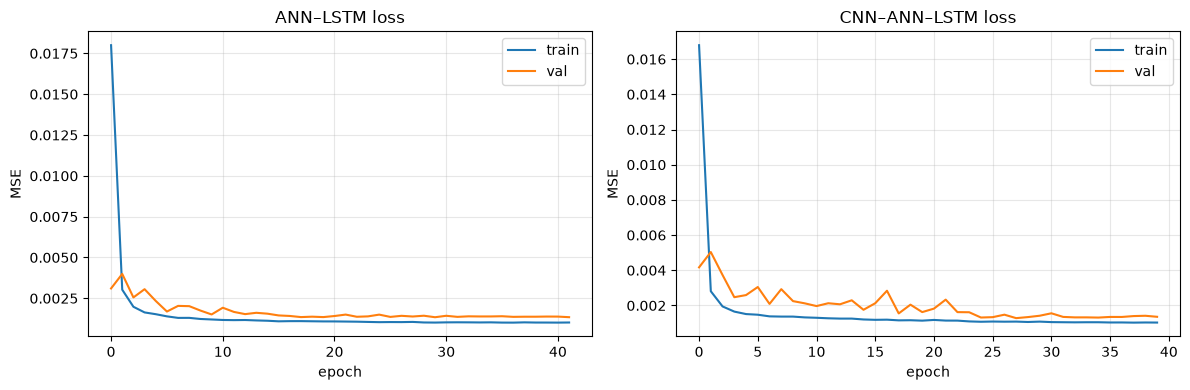

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, hist, title in [(axes[0], hist_ann, "ANN–LSTM"), (axes[1], hist_cnn, "CNN–ANN–LSTM")]:
    ax.plot(hist.history["loss"], label="train")
    ax.plot(hist.history["val_loss"], label="val")
    ax.set_title(f"{title} loss")
    ax.set_xlabel("epoch")
    ax.set_ylabel("MSE")
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / "lstm_training_curves.png", dpi=120)
plt.show()

## Baseline predictors (same test issues)

Persistence, existing 6-input forecast head, and PINN+bias — all scored on identical `meta_test` rows.

In [9]:
def predict_persistence(meta):
    return {h: (meta["sst_issue"].values.copy(), meta["dhw_issue"].values.copy()) for h in HORIZONS}


def predict_forecast_head(meta):
    path = "pinn_forecast_best.h5"
    if not os.path.exists(path):
        print("pinn_forecast_best.h5 not found — skip")
        return None
    model = keras.models.load_model(path, compile=False)
    with open("scalers.pkl", "rb") as f:
        sc = pickle.load(f)
    t_min = float(np.asarray(sc["scaler_time"].data_min_).ravel()[0])
    t_max = float(np.asarray(sc["scaler_time"].data_max_).ravel()[0])
    t_scale = max(t_max - t_min, 1e-8)

    # Batch by horizon for speed
    out = {}
    for h in HORIZONS:
        X = np.column_stack([
            transform(sc["scaler_lat"], meta["latitude"].values),
            transform(sc["scaler_lon"], meta["longitude"].values),
            (meta[f"days_t{h}"].values - t_min) / t_scale,
            np.full(len(meta), h / float(max(HORIZONS))),
            transform(sc["scaler_temp"], meta["sst_issue"].values),
            transform(sc["scaler_dhw"], meta["dhw_issue"].values),
        ]).astype(np.float32)
        pred = np.asarray(model.predict(X, verbose=0))
        if pred.ndim == 1:
            pred = pred.reshape(-1, 1)
        sst = inverse(sc["scaler_temp"], pred[:, 0])
        dhw = inverse(sc["scaler_dhw"], pred[:, 1]) if pred.shape[1] > 1 else np.zeros(len(meta))
        out[h] = (sst, dhw)
    print("Forecast head done:", path)
    return out


def predict_pinn_bias(meta, window_days=7):
    path = "pinn_model_best.h5"
    if not os.path.exists(path):
        print("pinn_model_best.h5 not found — skip")
        return None
    model = keras.models.load_model(path, compile=False)
    with open("scalers.pkl", "rb") as f:
        sc = pickle.load(f)
    t_min = float(np.asarray(sc["scaler_time"].data_min_).ravel()[0])
    t_max = float(np.asarray(sc["scaler_time"].data_max_).ravel()[0])
    t_scale = max(t_max - t_min, 1e-8)
    hist = df.sort_values(["location", "time"])

    out = {h: ([], []) for h in HORIZONS}
    for _, row in meta.iterrows():
        loc_hist = hist[hist["location"] == row["location"]]
        issue = row["time_issue"]
        win = loc_hist[
            (loc_hist["time"] > issue - pd.Timedelta(days=window_days))
            & (loc_hist["time"] <= issue)
        ]
        if len(win):
            xw = np.column_stack([
                transform(sc["scaler_lat"], win["latitude"].values),
                transform(sc["scaler_lon"], win["longitude"].values),
                (win["days"].values - t_min) / t_scale,
            ]).astype(np.float32)
            pw = np.asarray(model.predict(xw, verbose=0))
            if pw.ndim == 2 and pw.shape[1] > 1:
                pw = pw[:, 0]
            else:
                pw = pw.ravel()
            bias = float(np.mean(win["analysed_sst"].values - inverse(sc["scaler_temp"], pw)))
        else:
            bias = 0.0

        for h in HORIZONS:
            x = np.array([[
                transform(sc["scaler_lat"], [row["latitude"]])[0],
                transform(sc["scaler_lon"], [row["longitude"]])[0],
                (row[f"days_t{h}"] - t_min) / t_scale,
            ]], dtype=np.float32)
            p = np.asarray(model.predict(x, verbose=0)).ravel()
            sst = float(inverse(sc["scaler_temp"], [p[0]])[0] + bias)
            out[h][0].append(sst)
            out[h][1].append(np.nan)

    for h in HORIZONS:
        out[h] = (np.asarray(out[h][0]), np.asarray(out[h][1]))
    print("PINN+bias done:", path)
    return out

In [10]:
pred_ann = decode_multihorizon(ann_lstm.predict(X_test, verbose=0))
pred_cnn = decode_multihorizon(cnn_ann_lstm.predict(X_test, verbose=0))
pred_persist = predict_persistence(meta_test)
pred_head = predict_forecast_head(meta_test)
pred_pinn = predict_pinn_bias(meta_test)

methods = {
    "persistence": pred_persist,
    "ann_lstm": pred_ann,
    "cnn_ann_lstm": pred_cnn,
}
if pred_head is not None:
    methods["forecast_head_6in"] = pred_head
if pred_pinn is not None:
    methods["pinn_bias"] = pred_pinn

print("Methods:", list(methods.keys()))

Forecast head done: pinn_forecast_best.h5
PINN+bias done: pinn_model_best.h5
Methods: ['persistence', 'ann_lstm', 'cnn_ann_lstm', 'forecast_head_6in', 'pinn_bias']


## Scoreboard: SST MAE / RMSE

Honest bars: beat persistence at **3–7 days** if possible; 1-day persistence often wins.

In [11]:
rows = []
for h in HORIZONS:
    y_true = meta_test[f"sst_t{h}"].values
    persist_mae, _ = mae_rmse(y_true, pred_persist[h][0])
    for name, preds in methods.items():
        mae, rmse = mae_rmse(y_true, preds[h][0])
        rows.append({
            "horizon_days": h,
            "model": name,
            "sst_mae": mae,
            "sst_rmse": rmse,
            "skill_vs_persistence": 1.0 - mae / max(persist_mae, 1e-6),
            "n": len(y_true),
        })

scoreboard = pd.DataFrame(rows)
scoreboard.to_csv(OUT_DIR / "lstm_scoreboard.csv", index=False)
print(scoreboard.sort_values(["horizon_days", "sst_mae"]).to_string(index=False))

pivot = scoreboard.pivot(index="model", columns="horizon_days", values="sst_mae")
pivot.columns = [f"MAE_{c}d" for c in pivot.columns]
pivot = pivot.sort_values("MAE_7d")
pivot.to_csv(OUT_DIR / "lstm_mae_pivot.csv")
print("\nPivot (lower better):")
print(pivot.round(4).to_string())
pivot

 horizon_days             model  sst_mae  sst_rmse  skill_vs_persistence    n
            1          ann_lstm 0.153629  0.204120              0.017146 1680
            1       persistence 0.156310  0.209389              0.000000 1680
            1      cnn_ann_lstm 0.161117  0.211803             -0.030753 1680
            1 forecast_head_6in 0.201518  0.254779             -0.289221 1680
            1         pinn_bias 0.209293  0.270570             -0.338962 1680
            3          ann_lstm 0.228081  0.292632              0.048341 1680
            3      cnn_ann_lstm 0.235857  0.300818              0.015897 1680
            3       persistence 0.239667  0.309336              0.000000 1680
            3         pinn_bias 0.260041  0.332242             -0.085009 1680
            3 forecast_head_6in 0.284058  0.354234             -0.185221 1680
            7          ann_lstm 0.293872  0.371365              0.081016 1680
            7      cnn_ann_lstm 0.304928  0.384108              

,MAE_1d,MAE_3d,MAE_7d
model,,,
ann_lstm,0.153629,0.228081,0.293872
cnn_ann_lstm,0.161117,0.235857,0.304928
persistence,0.156310,0.239667,0.319780
pinn_bias,0.209293,0.260041,0.328416
forecast_head_6in,0.201518,0.284058,0.364106


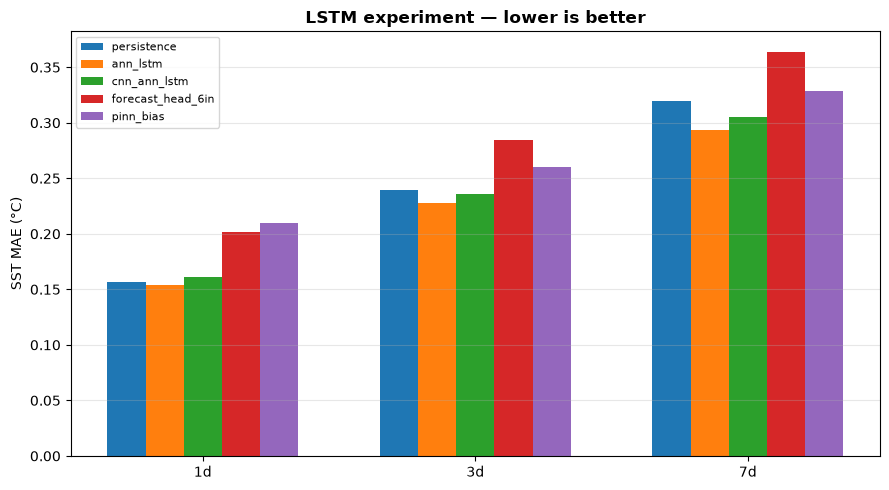

In [12]:
fig, ax = plt.subplots(figsize=(9, 5))
names = list(methods.keys())
x = np.arange(len(HORIZONS))
width = 0.14
for i, name in enumerate(names):
    vals = [
        scoreboard[(scoreboard.model == name) & (scoreboard.horizon_days == h)]["sst_mae"].iloc[0]
        for h in HORIZONS
    ]
    ax.bar(x + (i - len(names) / 2) * width + width / 2, vals, width, label=name)

ax.set_xticks(x)
ax.set_xticklabels([f"{h}d" for h in HORIZONS])
ax.set_ylabel("SST MAE (°C)")
ax.set_title("LSTM experiment — lower is better", fontweight="bold")
ax.legend(fontsize=8)
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / "lstm_mae_comparison.png", dpi=130)
plt.show()

## DHW forecast skill

In [13]:
dhw_rows = []
for h in HORIZONS:
    y_true = meta_test[f"dhw_t{h}"].values
    for name, preds in methods.items():
        if name == "pinn_bias":
            continue
        mae, rmse = mae_rmse(y_true, preds[h][1])
        dhw_rows.append({"horizon_days": h, "model": name, "dhw_mae": mae, "dhw_rmse": rmse})

dhw_board = pd.DataFrame(dhw_rows)
dhw_board.to_csv(OUT_DIR / "lstm_dhw_scoreboard.csv", index=False)
print(dhw_board.sort_values(["horizon_days", "dhw_mae"]).to_string(index=False))
dhw_board

 horizon_days             model  dhw_mae  dhw_rmse
            1       persistence 0.000000  0.000000
            1      cnn_ann_lstm 0.001934  0.004242
            1          ann_lstm 0.006837  0.016014
            1 forecast_head_6in 0.060344  0.066662
            3       persistence 0.000000  0.000000
            3      cnn_ann_lstm 0.002460  0.005538
            3          ann_lstm 0.007756  0.018890
            3 forecast_head_6in 0.064273  0.071406
            7       persistence 0.000000  0.000000
            7      cnn_ann_lstm 0.003310  0.007908
            7          ann_lstm 0.009446  0.023612
            7 forecast_head_6in 0.057423  0.067790


,horizon_days,model,dhw_mae,dhw_rmse
0,1,persistence,0.000000,0.000000
1,1,ann_lstm,0.006837,0.016014
2,1,cnn_ann_lstm,0.001934,0.004242
3,1,forecast_head_6in,0.060344,0.066662
4,3,persistence,0.000000,0.000000
5,3,ann_lstm,0.007756,0.018890
6,3,cnn_ann_lstm,0.002460,0.005538
7,3,forecast_head_6in,0.064273,0.071406
8,7,persistence,0.000000,0.000000
9,7,ann_lstm,0.009446,0.023612


## Bleaching-risk accuracy

Predicted SST+DHW → `calculate_bleaching_risk` → compare risk level (0/1/2) to truth.

In [14]:
baselines = {}
for loc in df["location"].unique():
    path = os.path.join("sliot_dataset", loc, "sst_full.csv")
    if os.path.exists(path):
        baselines[loc] = calculate_location_baseline(path)

risk_frames = []
for name in ["persistence", "ann_lstm", "cnn_ann_lstm"]:
    preds = methods[name]
    for h in HORIZONS:
        sst_hat, dhw_hat = preds[h]
        for k in range(len(meta_test)):
            row = meta_test.iloc[k]
            month = pd.Timestamp(row["time_issue"]).month
            base = baselines.get(row["location"], {}).get(month, 28.0)
            pred_risk = calculate_bleaching_risk(
                current_temp=float(sst_hat[k]),
                baseline_temp=base,
                recent_temps=[float(row["sst_issue"]), float(sst_hat[k])],
                dhw=float(dhw_hat[k]),
            )
            true_risk = calculate_bleaching_risk(
                current_temp=float(row[f"sst_t{h}"]),
                baseline_temp=base,
                recent_temps=[float(row["sst_issue"]), float(row[f"sst_t{h}"])],
                dhw=float(row[f"dhw_t{h}"]),
            )
            risk_frames.append({
                "model": name,
                "horizon_days": h,
                "pred_risk_level": pred_risk["risk_level"],
                "true_risk_level": true_risk["risk_level"],
            })

risk_df = pd.DataFrame(risk_frames)
risk_df["hit"] = risk_df["pred_risk_level"] == risk_df["true_risk_level"]
risk_acc = (
    risk_df.groupby(["model", "horizon_days"])["hit"]
    .mean()
    .reset_index()
    .rename(columns={"hit": "risk_level_accuracy"})
)
risk_acc.to_csv(OUT_DIR / "lstm_risk_accuracy.csv", index=False)
print(risk_acc.sort_values(["horizon_days", "risk_level_accuracy"], ascending=[True, False]).to_string(index=False))
risk_acc

       model  horizon_days  risk_level_accuracy
    ann_lstm             1                  1.0
cnn_ann_lstm             1                  1.0
 persistence             1                  1.0
    ann_lstm             3                  1.0
cnn_ann_lstm             3                  1.0
 persistence             3                  1.0
    ann_lstm             7                  1.0
cnn_ann_lstm             7                  1.0
 persistence             7                  1.0


,model,horizon_days,risk_level_accuracy
0,ann_lstm,1,1.0
1,ann_lstm,3,1.0
2,ann_lstm,7,1.0
3,cnn_ann_lstm,1,1.0
4,cnn_ann_lstm,3,1.0
5,cnn_ann_lstm,7,1.0
6,persistence,1,1.0
7,persistence,3,1.0
8,persistence,7,1.0


## Example forecast trace

Example: passikudha  issue=2025-09-08 12:00:00+00:00


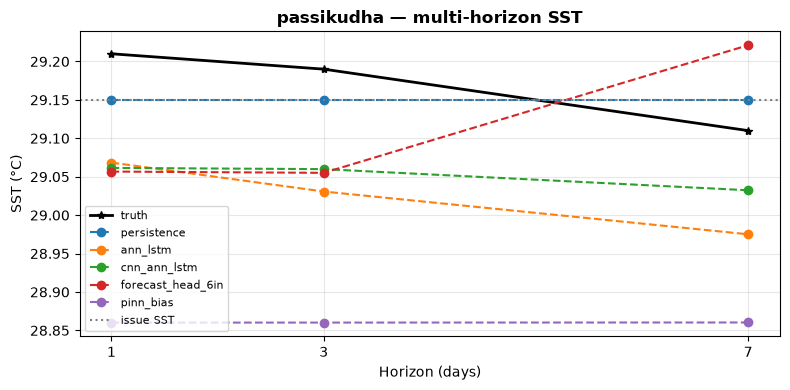

In [15]:
k = len(meta_test) // 2
row = meta_test.iloc[k]
print(f"Example: {row['location']}  issue={row['time_issue']}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(HORIZONS, [row[f"sst_t{h}"] for h in HORIZONS], "k*-" , label="truth", linewidth=2)
for name, preds in methods.items():
    ax.plot(HORIZONS, [preds[h][0][k] for h in HORIZONS], "o--", label=name)
ax.axhline(row["sst_issue"], color="gray", linestyle=":", label="issue SST")
ax.set_xticks(HORIZONS)
ax.set_xlabel("Horizon (days)")
ax.set_ylabel("SST (°C)")
ax.set_title(f"{row['location']} — multi-horizon SST", fontweight="bold")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / "lstm_example_trace.png", dpi=130)
plt.show()

## Verdict

In [16]:
print("=" * 70)
print("EXPERIMENT VERDICT")
print("=" * 70)
for h in HORIZONS:
    sub = scoreboard[scoreboard.horizon_days == h].sort_values("sst_mae")
    best = sub.iloc[0]
    persist = sub[sub.model == "persistence"].iloc[0]
    print(f"\n{h}-day:")
    print(f"  best     : {best['model']:20s}  MAE={best['sst_mae']:.4f} °C")
    print(f"  persist  : {'persistence':20s}  MAE={persist['sst_mae']:.4f} °C")
    if best["model"] != "persistence":
        print(f"  → learned model beats persistence by {persist['sst_mae'] - best['sst_mae']:.4f} °C")
    else:
        second = sub.iloc[1]
        print(f"  → persistence wins; closest={second['model']} "
              f"(Δ={second['sst_mae'] - persist['sst_mae']:.4f} °C)")

print("\nArtefacts in", OUT_DIR.resolve())
for p in sorted(OUT_DIR.glob("*")):
    print(" -", p.name)

EXPERIMENT VERDICT

1-day:
  best     : ann_lstm              MAE=0.1536 °C
  persist  : persistence           MAE=0.1563 °C
  → learned model beats persistence by 0.0027 °C

3-day:
  best     : ann_lstm              MAE=0.2281 °C
  persist  : persistence           MAE=0.2397 °C
  → learned model beats persistence by 0.0116 °C

7-day:
  best     : ann_lstm              MAE=0.2939 °C
  persist  : persistence           MAE=0.3198 °C
  → learned model beats persistence by 0.0259 °C

Artefacts in D:\corals\model\lstm_experiment
 - ann_lstm_best.h5
 - ann_lstm_final.h5
 - ann_lstm_history.csv
 - cnn_ann_lstm_best.h5
 - cnn_ann_lstm_final.h5
 - cnn_ann_lstm_history.csv
 - lstm_dhw_scoreboard.csv
 - lstm_example_trace.png
 - lstm_mae_comparison.png
 - lstm_mae_pivot.csv
 - lstm_risk_accuracy.csv
 - lstm_scoreboard.csv
 - lstm_training_curves.png


## Summary

Clear A/B experiment on the same test issues:

1. Persistence  
2. 6-input forecast head (`pinn_forecast_best.h5`)  
3. PINN + bias (`pinn_model_best.h5`)  
4. ANN–LSTM  
5. CNN–ANN–LSTM  

**Outputs** → `lstm_experiment/`

Optional next: sweep `LOOKBACK ∈ {30, 60, 84}`. If CNN–ANN–LSTM wins 3–7d, integrate later into a new forecaster path without touching existing notebooks.

**This notebook does not change any existing project files.**